In [1]:
#===========PART 1: DATA EXPLORATION==========
#1.=========import===========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2.==========loading datasets and info==========
burnout_df=pd.read_csv('Capstone Project DA/mental_health_workplace_survey.csv')
sleep_df=pd.read_csv('Capstone Project DA/Sleep_health_and_lifestyle_dataset.csv')
oecd_df=pd.read_csv('Capstone Project DA/Country_Comparision.csv')

#shape and column
print("----------BURNOUT DATASET--------- :\n",
      "\nSHAPE: ",burnout_df.shape,"\n",
      "\nCOLUMNS: ",burnout_df.columns.tolist(),"\n",
      "\nDATATYPES OF COL:\n",burnout_df.dtypes)
print("\n----------SLEEP DATASET----------- :\n",
      "\nSHAPE: ",sleep_df.shape,"\n", 
      "\nCOLUMNS: ",sleep_df.columns.tolist(),"\n",
      "\nDATATYPES OF COL:\n",sleep_df.dtypes)
print("\n----------OECD DATASET------------ :\n",
      "\nSHAPE: ",oecd_df.shape,"\n", 
      "\nCOLUMNS: ",oecd_df.columns.tolist(),"\n",
      "\nDATATYPES OF COL:\n",oecd_df.dtypes)


----------BURNOUT DATASET--------- :
 
SHAPE:  (3000, 25) 
 
COLUMNS:  ['EmployeeID', 'Age', 'Gender', 'Country', 'JobRole', 'Department', 'YearsAtCompany', 'WorkHoursPerWeek', 'RemoteWork', 'BurnoutLevel', 'JobSatisfaction', 'StressLevel', 'ProductivityScore', 'SleepHours', 'PhysicalActivityHrs', 'CommuteTime', 'HasMentalHealthSupport', 'ManagerSupportScore', 'HasTherapyAccess', 'MentalHealthDaysOff', 'SalaryRange', 'WorkLifeBalanceScore', 'TeamSize', 'CareerGrowthScore', 'BurnoutRisk'] 
 
DATATYPES OF COL:
 EmployeeID                  int64
Age                         int64
Gender                     object
Country                    object
JobRole                    object
Department                 object
YearsAtCompany              int64
WorkHoursPerWeek            int64
RemoteWork                 object
BurnoutLevel              float64
JobSatisfaction           float64
StressLevel               float64
ProductivityScore         float64
SleepHours                float64
PhysicalA

In [3]:
# 3.============checking missing values=============

print("--------BURNOUT-------- \n",burnout_df.isnull().sum())
print("--------SLEEP---------- \n", sleep_df.isnull().sum())
print("--------OECD---------- \n", oecd_df.isnull().sum())

#only col having missing values
print("-------BURNOUT---------\n",burnout_df.isnull().sum()[burnout_df.isnull().sum()>0])
print("-------SLEEP---------\n",sleep_df.isnull().sum()[sleep_df.isnull().sum()>0])
print("-------OECD---------\n",oecd_df.isnull().sum()[oecd_df.isnull().sum()>0])

total=len(sleep_df)
missing=sleep_df['Sleep Disorder'].isnull().sum()
percent=(missing/total)*100
print("missing percent of Sleep Disorder:", percent,"%")

print(sleep_df['Sleep Disorder'].unique())
print(sleep_df['Sleep Disorder'].value_counts())


             

--------BURNOUT-------- 
 EmployeeID                0
Age                       0
Gender                    0
Country                   0
JobRole                   0
Department                0
YearsAtCompany            0
WorkHoursPerWeek          0
RemoteWork                0
BurnoutLevel              0
JobSatisfaction           0
StressLevel               0
ProductivityScore         0
SleepHours                0
PhysicalActivityHrs       0
CommuteTime               0
HasMentalHealthSupport    0
ManagerSupportScore       0
HasTherapyAccess          0
MentalHealthDaysOff       0
SalaryRange               0
WorkLifeBalanceScore      0
TeamSize                  0
CareerGrowthScore         0
BurnoutRisk               0
dtype: int64
--------SLEEP---------- 
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level      

In [4]:
# 3.1=============handle null values=============
#as values are nan so fill the values as NONE
sleep_df['Sleep Disorder'] = sleep_df['Sleep Disorder'].fillna('None')
print(sleep_df['Sleep Disorder'].value_counts())



Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [5]:
#dropping missing values rows/col
#dropping cols of oecd as full row is missing
oecd_df.drop(columns=['Reference Period Code', 'Reference Period', 'Flag Codes', 'Flags'] ,inplace=True)
print(oecd_df.columns.tolist())

['LOCATION', 'Country', 'INDICATOR', 'Indicator', 'MEASURE', 'Measure', 'INEQUALITY', 'Inequality', 'Unit Code', 'Unit', 'PowerCode Code', 'PowerCode', 'Value']


In [6]:
# 4.==============duplicate rows=================
print(burnout_df.duplicated().sum())
print(sleep_df.duplicated().sum())
print(oecd_df.duplicated().sum())

0
0
0


In [7]:
# 5.stats on numerical cols
print("======BURNOUT=========")
display(burnout_df.describe())
print("======SLEEP===========")
display(sleep_df.describe())
print("======OECD============")
display(oecd_df.describe())

======BURNOUT=========


,EmployeeID,Age,YearsAtCompany,WorkHoursPerWeek,BurnoutLevel,JobSatisfaction,StressLevel,ProductivityScore,SleepHours,PhysicalActivityHrs,CommuteTime,ManagerSupportScore,MentalHealthDaysOff,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.00000,3000.00000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000
mean,2500.500000,40.805667,10.099333,44.504000,5.509137,5.43750,5.51535,5.51956,6.539000,5.030400,59.227000,5.44254,4.544667,5.450950,25.20100,5.520680,0.326667
std,866.169729,11.011705,6.035032,8.491526,2.574072,2.59443,2.60361,2.60761,1.441876,2.861026,34.809779,2.59740,2.854129,2.602379,14.08645,2.566861,0.469072
min,1001.000000,22.000000,0.000000,30.000000,1.000000,1.00000,1.00000,1.00000,4.000000,0.000000,0.000000,1.00000,0.000000,1.000000,1.00000,1.000000,0.000000
25%,1750.750000,31.000000,5.000000,37.000000,3.300000,3.18000,3.26000,3.28000,5.300000,2.600000,29.000000,3.16000,2.000000,3.160000,13.00000,3.300000,0.000000
50%,2500.500000,41.000000,10.000000,45.000000,5.480000,5.43000,5.49500,5.49000,6.600000,5.000000,59.000000,5.44000,5.000000,5.425000,25.00000,5.580000,0.000000
75%,3250.250000,50.000000,15.000000,52.000000,7.640000,7.68000,7.82250,7.80250,7.800000,7.500000,90.000000,7.69000,7.000000,7.730000,37.00000,7.642500,1.000000
max,4000.000000,59.000000,20.000000,59.000000,10.000000,10.00000,10.00000,10.00000,9.000000,10.000000,119.000000,9.99000,9.000000,10.000000,49.00000,9.990000,1.000000


======SLEEP===========


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


======OECD============


,PowerCode Code,Value
count,2369.0,2369.000000
mean,0.0,5299.220612
std,0.0,41894.336828
min,0.0,0.000000
25%,0.0,7.100000
50%,0.0,66.000000
75%,0.0,88.000000
max,0.0,941162.000000


In [8]:
# 6.check for outliers
def check_outliers(df,column):
    Q1=df[column].quantile(0.25) #values below 25% of data
    Q3=df[column].quantile(0.75) #values below 75%
    IQR=Q3-Q1                    #in between
    lower=Q1 -1.5*IQR            #least acceptable value
    upper=Q3 +1.5*IQR             #highest "" value
    outliers=df[(df[column]<lower)|(df[column]>upper)]
    print(f"{column}: {len(outliers)} outliers | Range: {lower:.1f} to {upper:.1f}")

#running on key col
print("==========Burnout Outliers==========\n")
for burnout_col in ['Age', 'WorkHoursPerWeek', 'BurnoutLevel', 'StressLevel', 'SleepHours', 'CommuteTime']:
    check_outliers(burnout_df,burnout_col)
print("\n*burnout dataset has zero outliers*\n")    
    
print("\n==========Sleep Outliers==========\n")
for sleep_col in ['Age', 'Sleep Duration',	'Quality of Sleep',	'Physical Activity Level',	'Stress Level',	'Heart Rate','Daily Steps']:
    check_outliers(sleep_df,sleep_col)   
print("\n*in Sleep dataset Heart Rate has 15 outliers*\n")

    

==========Burnout Outliers==========

Age: 0 outliers | Range: 2.5 to 78.5
WorkHoursPerWeek: 0 outliers | Range: 14.5 to 74.5
BurnoutLevel: 0 outliers | Range: -3.2 to 14.1
StressLevel: 0 outliers | Range: -3.6 to 14.7
SleepHours: 0 outliers | Range: 1.5 to 11.6
CommuteTime: 0 outliers | Range: -62.5 to 181.5

*burnout dataset has zero outliers*


==========Sleep Outliers==========

Age: 0 outliers | Range: 13.1 to 72.1
Sleep Duration: 0 outliers | Range: 4.3 to 9.9
Quality of Sleep: 0 outliers | Range: 3.0 to 11.0
Physical Activity Level: 0 outliers | Range: 0.0 to 120.0
Stress Level: 0 outliers | Range: -0.5 to 11.5
Heart Rate: 15 outliers | Range: 62.0 to 78.0
Daily Steps: 0 outliers | Range: 2000.0 to 11600.0

*in Sleep dataset Heart Rate has 15 outliers*



In [9]:
# 6.1 for oecd----------- 
print("========OECD OUTLIERS========")
print(oecd_df.columns.tolist())
print(oecd_df.head(10))
print(oecd_df['Indicator'].value_counts())

========OECD OUTLIERS========
['LOCATION', 'Country', 'INDICATOR', 'Indicator', 'MEASURE', 'Measure', 'INEQUALITY', 'Inequality', 'Unit Code', 'Unit', 'PowerCode Code', 'PowerCode', 'Value']
  LOCATION         Country INDICATOR                 Indicator MEASURE  \
0      AUS       Australia   JE_LMIS  Labour market insecurity       L   
1      AUT         Austria   JE_LMIS  Labour market insecurity       L   
2      BEL         Belgium   JE_LMIS  Labour market insecurity       L   
3      CAN          Canada   JE_LMIS  Labour market insecurity       L   
4      CZE  Czech Republic   JE_LMIS  Labour market insecurity       L   
5      DNK         Denmark   JE_LMIS  Labour market insecurity       L   
6      FIN         Finland   JE_LMIS  Labour market insecurity       L   
7      FRA          France   JE_LMIS  Labour market insecurity       L   
8      DEU         Germany   JE_LMIS  Labour market insecurity       L   
9      GRC          Greece   JE_LMIS  Labour market insecurity       

In [10]:
#6.2.keeping only related indicators
relevant_indicator= [
    # Work related
    'Employees working very long hours',
    'Long-term unemployment rate',
    'Employment rate',
    'Time devoted to leisure and personal care',
    
    # Health related
    'Life satisfaction',
    'Self-reported health',
    'Life expectancy',
    
    # Environmental health
    'Water quality',
    'Air pollution'
]


oecd_filtered=oecd_df[oecd_df['Indicator'].isin(relevant_indicator)]


print("shape after filtering:",oecd_filtered.shape)
print(oecd_filtered['Indicator'].value_counts())

oecd_df.drop(columns=['LOCATION', 'INDICATOR', 'MEASURE', 
                       'INEQUALITY', 'Unit Code', 
                       'PowerCode Code', 'PowerCode'], inplace=True)

print(oecd_df.columns.tolist())

shape after filtering: (1131, 13)
Indicator
Life satisfaction                            208
Self-reported health                         194
Employment rate                              126
Water quality                                126
Life expectancy                              126
Long-term unemployment rate                  120
Employees working very long hours            120
Time devoted to leisure and personal care     69
Air pollution                                 42
Name: count, dtype: int64
['Country', 'Indicator', 'Measure', 'Inequality', 'Unit', 'Value']


In [11]:
# 6.3.now checking outliers per indicator separately 
for indicate in relevant_indicator:
    subset=oecd_filtered[oecd_filtered['Indicator']==indicate]['Value']
    Q1=subset.quantile(0.25)
    Q3=subset.quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5+IQR
    outliers=subset[(subset<lower)|(subset>upper)]
    print(f"{indicate}: {len(outliers)} outliers | Range: {lower:.1f} to {upper:.1f}")
    
print("\nin oecd dataset all indicators have outliers")

Employees working very long hours: 12 outliers | Range: -9.6 to 19.0
Long-term unemployment rate: 7 outliers | Range: -1.5 to 5.3
Employment rate: 12 outliers | Range: 51.5 to 84.5
Time devoted to leisure and personal care: 0 outliers | Range: 13.3 to 17.8
Life satisfaction: 1 outliers | Range: 4.7 to 9.8
Self-reported health: 6 outliers | Range: 34.0 to 98.5
Life expectancy: 6 outliers | Range: 72.0 to 89.2
Water quality: 3 outliers | Range: 61.0 to 104.5
Air pollution: 3 outliers | Range: -3.7 to 26.8

in oecd dataset all indicators have outliers


In [12]:
#handling outliers of 
print("===Sleep Dataset Outlier Handling===")
sleep_df=sleep_df[sleep_df['Heart Rate']<=100] #keeps only True value
sleep_df=sleep_df[sleep_df['Sleep Duration']<=12] 
print("Sleep shape after cleaning:",sleep_df.shape)

===Sleep Dataset Outlier Handling===
Sleep shape after cleaning: (374, 13)


In [13]:
#OECD Outlier handing 
#all can have outliers just chcekking hor negative ranges
print(oecd_filtered[oecd_filtered['Indicator']=='Employees working very long hours']['Value'].min())
#all values are actual so no need to handle outliers of oecd

0.1


In [14]:
# 7. Checking Inconsistencies (Unique values)
print("=========UNIQUE VALUES OF==========")
print("\n=====BURNOUT=======")
for col in burnout_df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(burnout_df[col].unique())
print("\n=======SLEEP========")
for col in sleep_df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(sleep_df[col].unique())
print("\n=======OECD=======")
print(oecd_filtered['Country'].unique())



=========UNIQUE VALUES OF==========

=====BURNOUT=======

Gender:
['Male' 'Non-binary' 'Prefer not to say' 'Female']

Country:
['UK' 'Germany' 'India' 'Australia' 'Brazil' 'USA' 'Canada']

JobRole:
['Sales Associate' 'Software Engineer' 'IT Admin' 'HR Specialist'
 'Customer Support' 'Project Manager' 'Marketing Manager' 'Data Scientist']

Department:
['HR' 'IT' 'Support' 'Engineering' 'Marketing' 'Sales']

RemoteWork:
['No' 'Hybrid' 'Yes']

HasMentalHealthSupport:
['No' 'Yes']

HasTherapyAccess:
['Yes' 'No']

SalaryRange:
['40K-60K' '80K-100K' '60K-80K' '<40K' '100K+']

=======SLEEP========

Gender:
['Male' 'Female']

Occupation:
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']

BMI Category:
['Overweight' 'Normal' 'Obese' 'Normal Weight']

Blood Pressure:
['126/83' '125/80' '140/90' '120/80' '132/87' '130/86' '117/76' '118/76'
 '128/85' '131/86' '128/84' '115/75' '135/88' '129/84' '130/85' '11

In [15]:
# 7.1 handling inconsistencies
#in sleep :BMI and Occupation
sleep_df['BMI Category']=sleep_df['BMI Category'].replace('Normal','Normal Weight')
sleep_df['Occupation']=sleep_df['Occupation'].replace('Salesperson','Sales Representative')
print(sleep_df['BMI Category'].unique())
print(sleep_df['Occupation'].unique())

#in oecd: oecd-total is not a country but an average so separating them
oecd_average=oecd_filtered[oecd_filtered['Country']=='OECD - Total']
oecd_countries=oecd_filtered[oecd_filtered['Country']!='OECD - Total']

print("Real countries:", oecd_countries['Country'].nunique())
print("OECD average rows:", oecd_average.shape[0])

['Overweight' 'Normal Weight' 'Obese']
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Manager']
Real countries: 41
OECD average rows: 29


In [16]:
#================ PART 2: Data CLEANING===================
# 1. standardize col name
def clean_col(df):
    df.columns=df.columns.str.strip()   #remove spaces around name
    df.columns=df.columns.str.lower()   #make lowercase
    df.columns=df.columns.str.replace(' ','_')
    df.columns=df.columns.str.replace('-','_')
    return df

burnout_df=clean_col(burnout_df)
sleep_df=clean_col(sleep_df)
oecd_countries=clean_col(oecd_countries)
oecd_average=clean_col(oecd_average)

print("BURNOUT columns:")
print(burnout_df.columns.tolist())
print("\nSLEEP columns:")
print(sleep_df.columns.tolist())
print("\nOECD columns:")
print(oecd_countries.columns.tolist())

BURNOUT columns:
['employeeid', 'age', 'gender', 'country', 'jobrole', 'department', 'yearsatcompany', 'workhoursperweek', 'remotework', 'burnoutlevel', 'jobsatisfaction', 'stresslevel', 'productivityscore', 'sleephours', 'physicalactivityhrs', 'commutetime', 'hasmentalhealthsupport', 'managersupportscore', 'hastherapyaccess', 'mentalhealthdaysoff', 'salaryrange', 'worklifebalancescore', 'teamsize', 'careergrowthscore', 'burnoutrisk']

SLEEP columns:
['person_id', 'gender', 'age', 'occupation', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level', 'stress_level', 'bmi_category', 'blood_pressure', 'heart_rate', 'daily_steps', 'sleep_disorder']

OECD columns:
['location', 'country', 'indicator', 'indicator', 'measure', 'measure', 'inequality', 'inequality', 'unit_code', 'unit', 'powercode_code', 'powercode', 'value']


In [17]:
# 1.1 burnout dataset
burnout_df = burnout_df.rename(columns={
    'employeeid': 'employee_id',
    'jobrole': 'job_role',
    'yearsatcompany': 'years_at_company',
    'workhoursperweek': 'work_hours_per_week',
    'remotework': 'remote_work',
    'burnoutlevel': 'burnout_level',
    'jobsatisfaction': 'job_satisfaction',
    'stresslevel': 'stress_level',
    'productivityscore': 'productivity_score',
    'sleephours': 'sleep_hours',
    'physicalactivityhrs': 'physical_activity_hrs',
    'commutetime': 'commute_time',
    'hasmentalhealthsupport': 'has_mental_health_support',
    'managersupportscore': 'manager_support_score',
    'hastherapyaccess': 'has_therapy_access',
    'mentalhealthdaysoff': 'mental_health_days_off',
    'salaryrange': 'salary_range',
    'worklifebalancescore': 'work_life_balance_score',
    'teamsize': 'team_size',
    'careergrowthscore': 'career_growth_score',
    'burnoutrisk': 'burnout_risk'
})
print(burnout_df.columns.tolist())

['employee_id', 'age', 'gender', 'country', 'job_role', 'department', 'years_at_company', 'work_hours_per_week', 'remote_work', 'burnout_level', 'job_satisfaction', 'stress_level', 'productivity_score', 'sleep_hours', 'physical_activity_hrs', 'commute_time', 'has_mental_health_support', 'manager_support_score', 'has_therapy_access', 'mental_health_days_off', 'salary_range', 'work_life_balance_score', 'team_size', 'career_growth_score', 'burnout_risk']


In [18]:
# 1.2 oecd dataset
print(oecd_countries.columns.tolist())
print(oecd_countries.shape)

['location', 'country', 'indicator', 'indicator', 'measure', 'measure', 'inequality', 'inequality', 'unit_code', 'unit', 'powercode_code', 'powercode', 'value']
(1102, 13)


In [19]:
#1.2.1 
#check col positions
for i,col in enumerate(oecd_countries.columns):
    print(i,col)

0 location
1 country
2 indicator
3 indicator
4 measure
5 measure
6 inequality
7 inequality
8 unit_code
9 unit
10 powercode_code
11 powercode
12 value


In [20]:
# 1.2.2 selecting only imp cols
oecd_clean=oecd_countries.iloc[:,[1,3,7,9,12]].copy()
oecd_clean.columns=['country','indicator','inequality','unit','value']
print(oecd_clean.columns.tolist())
print(oecd_clean.head())

['country', 'indicator', 'inequality', 'unit', 'value']
            country        indicator inequality        unit  value
360       Australia  Employment rate      Total  Percentage   73.0
361         Austria  Employment rate      Total  Percentage   72.0
362         Belgium  Employment rate      Total  Percentage   65.0
363          Canada  Employment rate      Total  Percentage   70.0
364  Czech Republic  Employment rate      Total  Percentage   74.0


In [21]:
# 2. fixing datatypes
print("BURNOUT dtypes:")
print(burnout_df.dtypes)

print("\nSLEEP dtypes:")
print(sleep_df.dtypes)

print("\nOECD dtypes:")
print(oecd_clean.dtypes)

BURNOUT dtypes:
employee_id                    int64
age                            int64
gender                        object
country                       object
job_role                      object
department                    object
years_at_company               int64
work_hours_per_week            int64
remote_work                   object
burnout_level                float64
job_satisfaction             float64
stress_level                 float64
productivity_score           float64
sleep_hours                  float64
physical_activity_hrs        float64
commute_time                   int64
has_mental_health_support     object
manager_support_score        float64
has_therapy_access            object
mental_health_days_off         int64
salary_range                  object
work_life_balance_score      float64
team_size                      int64
career_growth_score          float64
burnout_risk                   int64
dtype: object

SLEEP dtypes:
person_id                    i

In [22]:
# 3. splitting datatype 
sleep_df[['systolic_bp','diastolic_bp']]=sleep_df['blood_pressure'].str.split('/',expand=True)
sleep_df['systolic_bp']=sleep_df['systolic_bp'].astype(int)
sleep_df['diastolic_bp']=sleep_df['diastolic_bp'].astype(int)
print(sleep_df[['blood_pressure', 'systolic_bp', 'diastolic_bp']].head())
print(sleep_df.dtypes)

  blood_pressure  systolic_bp  diastolic_bp
0         126/83          126            83
1         125/80          125            80
2         125/80          125            80
3         140/90          140            90
4         140/90          140            90
person_id                    int64
gender                      object
age                          int64
occupation                  object
sleep_duration             float64
quality_of_sleep             int64
physical_activity_level      int64
stress_level                 int64
bmi_category                object
blood_pressure              object
heart_rate                   int64
daily_steps                  int64
sleep_disorder              object
systolic_bp                  int64
diastolic_bp                 int64
dtype: object


In [23]:
# creating new cols
sleep_df['high_bp'] = (sleep_df['systolic_bp'] >= 130) | (sleep_df['diastolic_bp'] >= 80)
print(sleep_df['high_bp'].value_counts())

high_bp
True     332
False     42
Name: count, dtype: int64


In [24]:
#high burnout
burnout_df['high_burnout']=burnout_df['burnout_level']>=7
print(burnout_df['high_burnout'].value_counts())
      


high_burnout
False    2016
True      984
Name: count, dtype: int64


In [25]:
#overworked
burnout_df['overworked']=burnout_df['work_hours_per_week']>45
print(burnout_df['overworked'].value_counts())

overworked
False    1595
True     1405
Name: count, dtype: int64


In [26]:
#poor sleep
sleep_df['poor_sleep'] = sleep_df['sleep_duration'] < 6
print(sleep_df['poor_sleep'].value_counts())

poor_sleep
False    368
True       6
Name: count, dtype: int64


In [27]:
def age_group(age):
    if age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    elif age < 55:
        return '45-54'
    else:
        return '55+'

burnout_df['age_group'] = burnout_df['age'].apply(age_group)
sleep_df['age_group'] = sleep_df['age'].apply(age_group)

print(burnout_df['age_group'].value_counts())
print(sleep_df['age_group'].value_counts())

age_group
45-54    803
35-44    777
25-34    763
55+      422
18-24    235
Name: count, dtype: int64
age_group
35-44    168
45-54     89
25-34     82
55+       35
Name: count, dtype: int64


In [28]:
# merging datasets
#merging oecd with burnout because both have country as foreign key
#converting oecd long format into wide format for merging
#A pivot table for rotating data: rows into columns.
oecd_wide=oecd_clean.pivot_table(index='country',columns='indicator',values='value').reset_index()
oecd_wide.columns=oecd_wide.columns.str.lower().str.replace(' ','_').str.replace('-','_')
print(oecd_wide.shape)
print('oecd wide columns:',oecd_wide.columns.tolist())
print(oecd_wide.head())

(41, 10)
oecd wide columns: ['country', 'air_pollution', 'employees_working_very_long_hours', 'employment_rate', 'life_expectancy', 'life_satisfaction', 'long_term_unemployment_rate', 'self_reported_health', 'time_devoted_to_leisure_and_personal_care', 'water_quality']
indicator    country  air_pollution  employees_working_very_long_hours  \
0          Australia            6.7                          12.366667   
1            Austria           12.2                           5.266667   
2            Belgium           12.8                           4.233333   
3             Brazil           11.7                           5.500000   
4             Canada            7.1                           3.266667   

indicator  employment_rate  life_expectancy  life_satisfaction  \
0                73.000000        82.966667               7.16   
1                72.000000        81.966667               7.28   
2                64.666667        82.066667               6.88   
3                57.0

In [29]:
print("Burnout countries:", sorted(burnout_df['country'].unique()))
print("\nOECD countries:", sorted(oecd_wide['country'].unique()))


Burnout countries: ['Australia', 'Brazil', 'Canada', 'Germany', 'India', 'UK', 'USA']

OECD countries: ['Australia', 'Austria', 'Belgium', 'Brazil', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Portugal', 'Russia', 'Slovak Republic', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 'United Kingdom', 'United States']


In [30]:
#india not part of oecd member country
burnout_df['country']=burnout_df['country'].replace({
    'UK':'United Kingdom',
    'USA':'United States'
})
print(burnout_df['country'].unique())

['United Kingdom' 'Germany' 'India' 'Australia' 'Brazil' 'United States'
 'Canada']


In [31]:
#merge oecd and burnout
final_merged_df=burnout_df.merge(oecd_wide,on='country',how='left')
print('Shape before merge:',burnout_df.shape)
print("Shape after merge:", final_merged_df.shape)
print(final_merged_df.columns.tolist())

Shape before merge: (3000, 28)
Shape after merge: (3000, 37)
['employee_id', 'age', 'gender', 'country', 'job_role', 'department', 'years_at_company', 'work_hours_per_week', 'remote_work', 'burnout_level', 'job_satisfaction', 'stress_level', 'productivity_score', 'sleep_hours', 'physical_activity_hrs', 'commute_time', 'has_mental_health_support', 'manager_support_score', 'has_therapy_access', 'mental_health_days_off', 'salary_range', 'work_life_balance_score', 'team_size', 'career_growth_score', 'burnout_risk', 'high_burnout', 'overworked', 'age_group', 'air_pollution', 'employees_working_very_long_hours', 'employment_rate', 'life_expectancy', 'life_satisfaction', 'long_term_unemployment_rate', 'self_reported_health', 'time_devoted_to_leisure_and_personal_care', 'water_quality']


In [32]:
# Checking India rows should show NaN for OECD columns
print(final_merged_df[final_merged_df['country'] == 'India'].head(2))

#  Germany rows - should show actual OECD values
print(final_merged_df[final_merged_df['country'] == 'Germany'].head(2))

# Checking for any missing values created by merge
print(final_merged_df.isnull().sum())

    employee_id  age             gender country  job_role department  \
2          1003   29         Non-binary   India  IT Admin         IT   
13         1014   23  Prefer not to say   India  IT Admin      Sales   

    years_at_company  work_hours_per_week remote_work  burnout_level  ...  \
2                 13                   59      Hybrid           7.10  ...   
13                 0                   50         Yes           2.43  ...   

    age_group  air_pollution  employees_working_very_long_hours  \
2       25-34            NaN                                NaN   
13      18-24            NaN                                NaN   

    employment_rate  life_expectancy  life_satisfaction  \
2               NaN              NaN                NaN   
13              NaN              NaN                NaN   

   long_term_unemployment_rate  self_reported_health  \
2                          NaN                   NaN   
13                         NaN                   NaN   

  

In [33]:
print(burnout_df[burnout_df['country'] == 'India'].shape[0])

464


In [34]:
missing_leisure = final_merged_df[final_merged_df['time_devoted_to_leisure_and_personal_care'].isnull()]
print(missing_leisure['country'].unique())

['India' 'Brazil']


In [35]:
brazil_data = oecd_wide[oecd_wide['country'] == 'Brazil']
print(brazil_data.T) 

                                                   3
indicator                                           
country                                       Brazil
air_pollution                                   11.7
employees_working_very_long_hours                5.5
employment_rate                                 57.0
life_expectancy                                 75.9
life_satisfaction                               6.32
long_term_unemployment_rate                      NaN
self_reported_health                             NaN
time_devoted_to_leisure_and_personal_care        NaN
water_quality                              70.333333


In [36]:
#saving all the datasets
final_merged_df.to_csv('Cleaned_datasets/final_merged_burnout_oecd.csv', index=False)
sleep_df.to_csv('Cleaned_datasets/sleep_df.csv', index=False)
oecd_wide.to_csv('Cleaned_datasets/oecd_wide_country_data.csv', index=False)

print("All files saved successfully!")
print("Final merged shape:", final_merged_df.shape)
print("Sleep shape:", sleep_df.shape)
print("OECD wide shape:", oecd_wide.shape)

All files saved successfully!
Final merged shape: (3000, 37)
Sleep shape: (374, 18)
OECD wide shape: (41, 10)


In [37]:
#============EDA================
print("Performing EDA with visualization on cleaned data now")


Performing EDA with visualization on cleaned data now


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#setting styles for charts
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(12,16)
plt.rcParams['font.size']=12



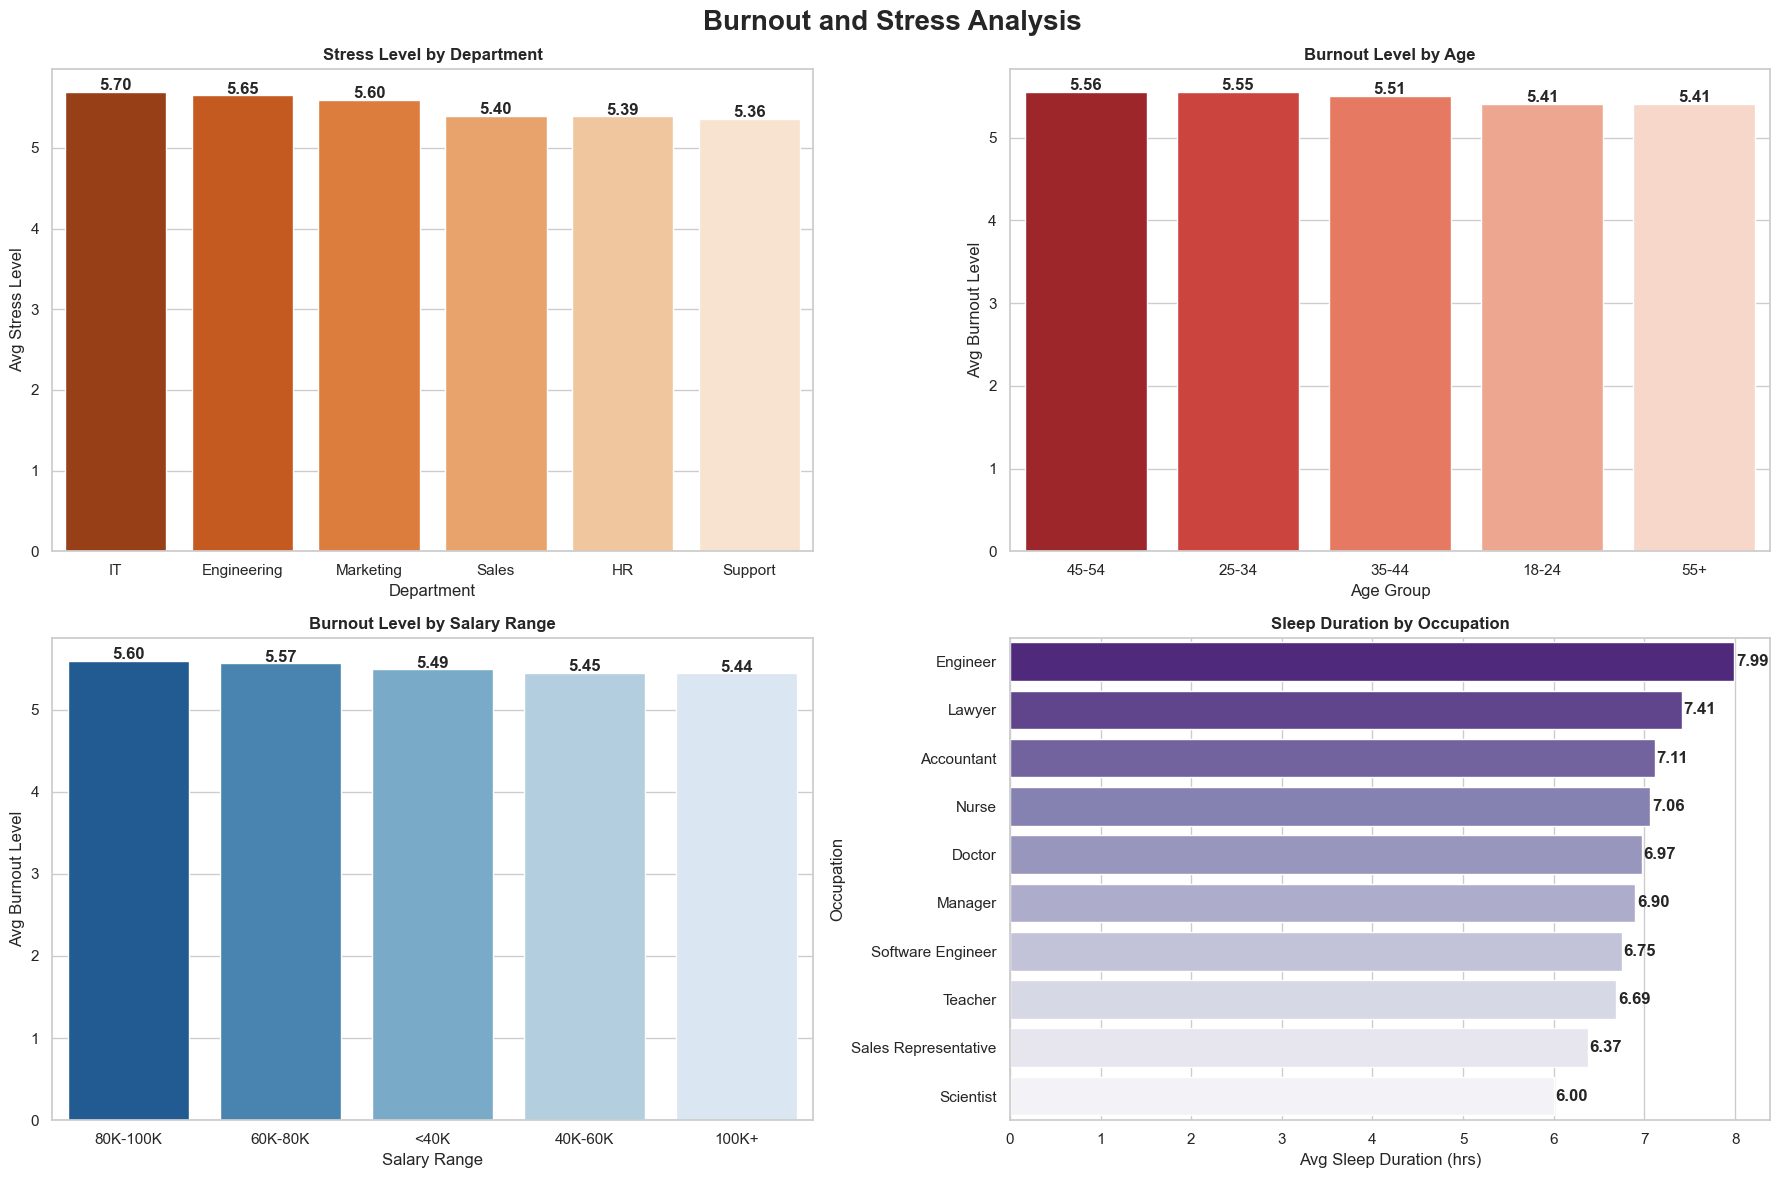

All bar charts saved!


In [39]:
fig, axes=plt.subplots(2,2,figsize=(18,12))
fig.suptitle('Burnout and Stress Analysis',fontsize=20,fontweight='bold')
#1.department vs stress
dept_stress=final_merged_df.groupby('department')['stress_level'].mean().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[0,0],data=dept_stress,x='department',y='stress_level',palette='Oranges_r',hue='department',legend=False)
axes[0,0].set_title('Stress Level by Department',fontweight='bold')
axes[0,0].set_xlabel('Department')
axes[0,0].set_ylabel('Avg Stress Level')
for i,v in enumerate(dept_stress['stress_level']):
    axes[0,0].text(i,v+0.02,f'{v:.2f}',ha='center',fontweight='bold')

#2.age group vs burnout
age_burnout=final_merged_df.groupby('age_group')['burnout_level'].mean().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[0,1],data=age_burnout,x='age_group',y='burnout_level',palette='Reds_r',hue='age_group',legend=False)
axes[0,1].set_title('Burnout Level by Age',fontweight='bold')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Avg Burnout Level')
for i,v in enumerate(age_burnout['burnout_level']):
    axes[0,1].text(i,v+0.02,f'{v:.2f}',ha='center',fontweight='bold')

#3.Salary vs Burnout
salary_burnout = final_merged_df.groupby('salary_range')['burnout_level'].mean().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[1,0], data=salary_burnout, x='salary_range', y='burnout_level', palette='Blues_r', hue='salary_range', legend=False)
axes[1,0].set_title('Burnout Level by Salary Range', fontweight='bold')
axes[1,0].set_xlabel('Salary Range')
axes[1,0].set_ylabel('Avg Burnout Level')
for i, v in enumerate(salary_burnout['burnout_level']):
    axes[1,0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

#4.Occupation vs Sleep
occ_sleep = sleep_df.groupby('occupation')['sleep_duration'].mean().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[1,1], data=occ_sleep, x='sleep_duration', y='occupation', palette='Purples_r', hue='occupation', legend=False)
axes[1,1].set_title('Sleep Duration by Occupation', fontweight='bold')
axes[1,1].set_xlabel('Avg Sleep Duration (hrs)')
axes[1,1].set_ylabel('Occupation')
for i, v in enumerate(occ_sleep['sleep_duration']):
    axes[1,1].text(v + 0.02, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout() #automatically adjusts spacing
plt.savefig('bar_charts_analysis.png', dpi=150)
plt.show()
print("All bar charts saved!")
    

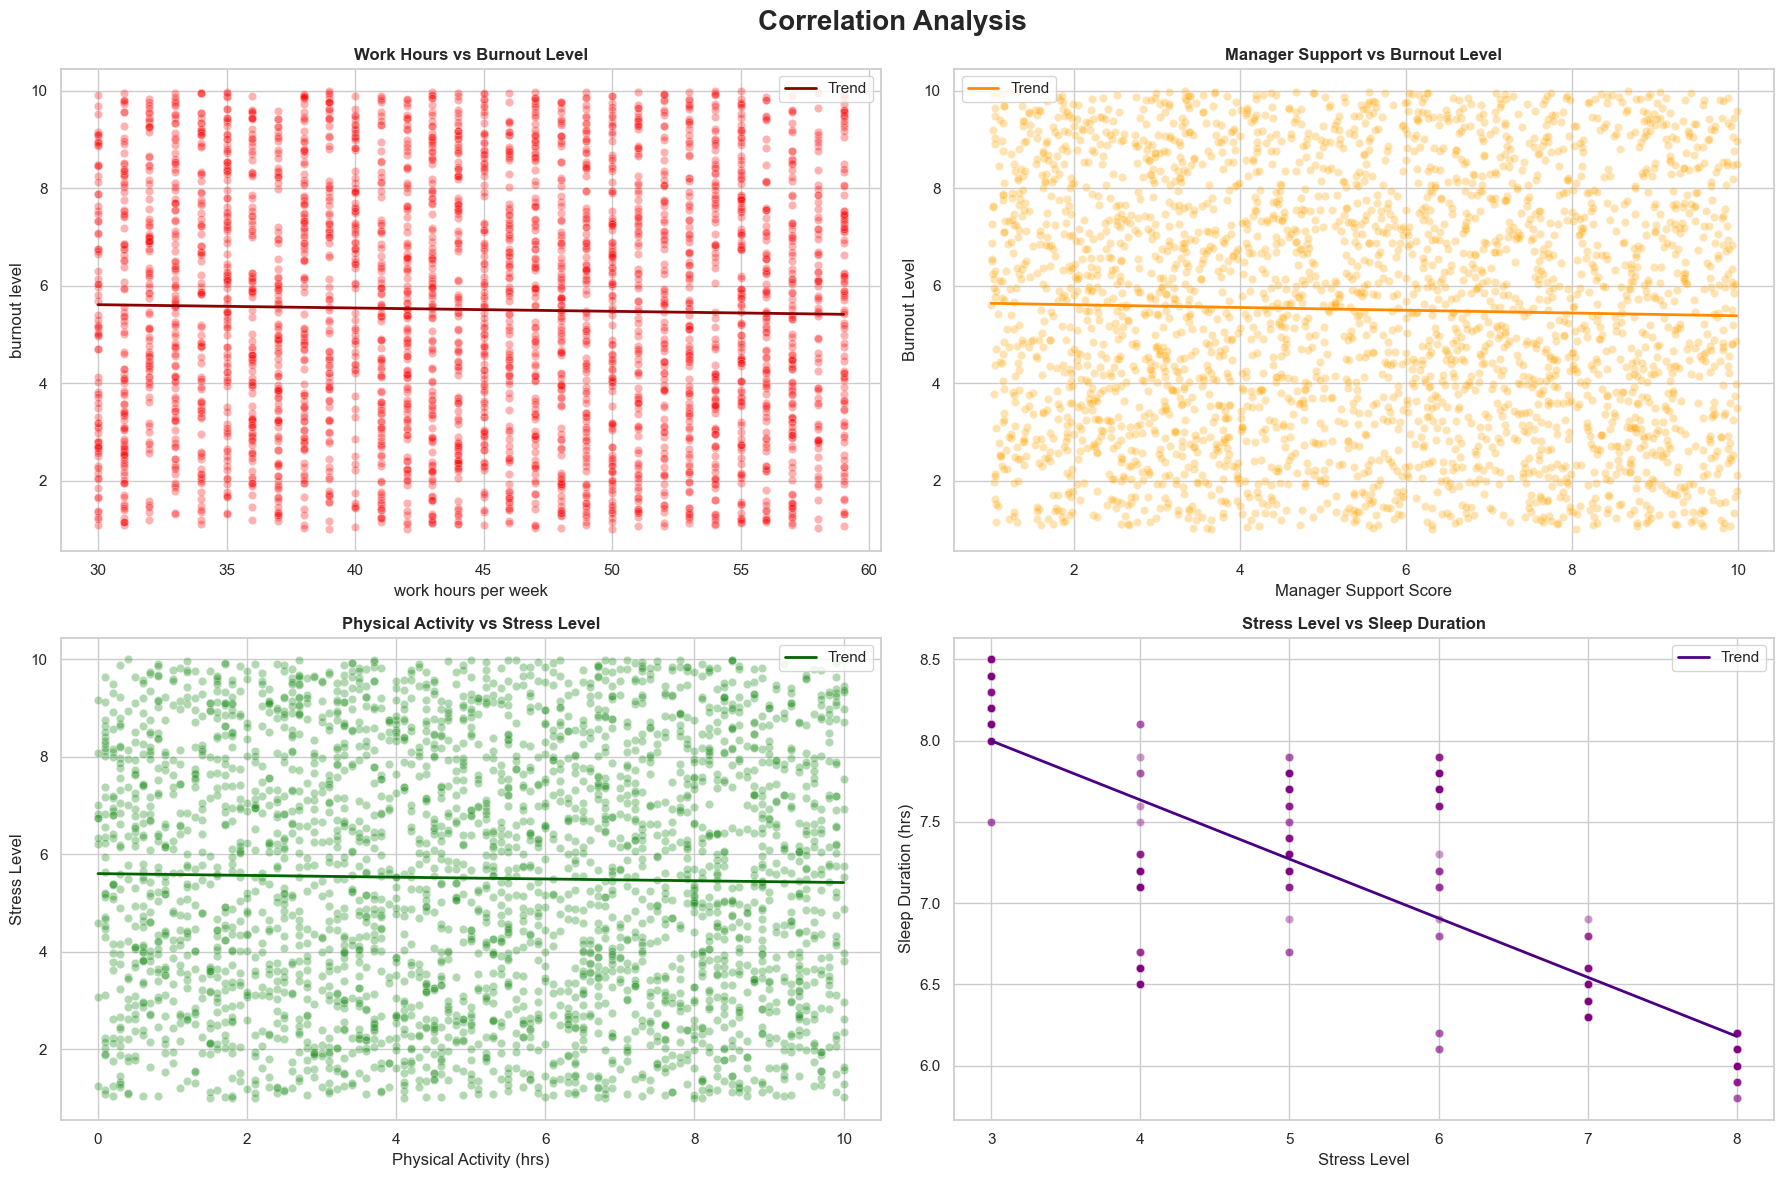

Scatter plots saved!


In [40]:
fig,axes=plt.subplots(2,2,figsize=(18,12))
fig.suptitle('Correlation Analysis',fontsize=20,fontweight='bold')

#1. work hours vs burnout
sns.scatterplot(ax=axes[0,0],data=final_merged_df,x='work_hours_per_week',y='burnout_level',alpha=0.3,color='red')
axes[0,0].set_title('Work Hours vs Burnout Level',fontweight='bold')
axes[0,0].set_xlabel('work hours per week')
axes[0,0].set_ylabel('burnout level')
#trend line
m,b=np.polyfit(final_merged_df['work_hours_per_week'],
              final_merged_df['burnout_level'],1)  #1 means st. line
axes[0,0].plot(
    sorted(final_merged_df['work_hours_per_week']),
    [m*x+b for x in sorted(final_merged_df['work_hours_per_week'])],  #ycoordinate
    color='darkred',
    linewidth=2,
    label='Trend'
)    
axes[0,0].legend()

#2. Manager Support vs Burnout
sns.scatterplot(ax=axes[0,1], data=final_merged_df,
                x='manager_support_score', y='burnout_level',
                alpha=0.3, color='orange')
axes[0,1].set_title('Manager Support vs Burnout Level', fontweight='bold')
axes[0,1].set_xlabel('Manager Support Score')
axes[0,1].set_ylabel('Burnout Level')

m, b = np.polyfit(final_merged_df['manager_support_score'],
                   final_merged_df['burnout_level'], 1)
axes[0,1].plot(sorted(final_merged_df['manager_support_score']),
               [m*x+b for x in sorted(final_merged_df['manager_support_score'])],
               color='darkorange', linewidth=2, label='Trend')
axes[0,1].legend()

# 3. Physical Activity vs Stress
sns.scatterplot(ax=axes[1,0], data=final_merged_df,
                x='physical_activity_hrs', y='stress_level',
                alpha=0.3, color='green')
axes[1,0].set_title('Physical Activity vs Stress Level', fontweight='bold')
axes[1,0].set_xlabel('Physical Activity (hrs)')
axes[1,0].set_ylabel('Stress Level')

m, b = np.polyfit(final_merged_df['physical_activity_hrs'],
                   final_merged_df['stress_level'], 1)
axes[1,0].plot(sorted(final_merged_df['physical_activity_hrs']),
               [m*x+b for x in sorted(final_merged_df['physical_activity_hrs'])],
               color='darkgreen', linewidth=2, label='Trend')
axes[1,0].legend()

# 4. Stress vs Sleep Duration (sleep_df)
sns.scatterplot(ax=axes[1,1], data=sleep_df,
                x='stress_level', y='sleep_duration',
                alpha=0.4, color='purple')
axes[1,1].set_title('Stress Level vs Sleep Duration', fontweight='bold')
axes[1,1].set_xlabel('Stress Level')
axes[1,1].set_ylabel('Sleep Duration (hrs)')

m, b = np.polyfit(sleep_df['stress_level'],
                   sleep_df['sleep_duration'], 1)
axes[1,1].plot(sorted(sleep_df['stress_level']),
               [m*x+b for x in sorted(sleep_df['stress_level'])],
               color='indigo', linewidth=2, label='Trend')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('scatter_plots_analysis.png', dpi=150)
plt.show()
print("Scatter plots saved!")


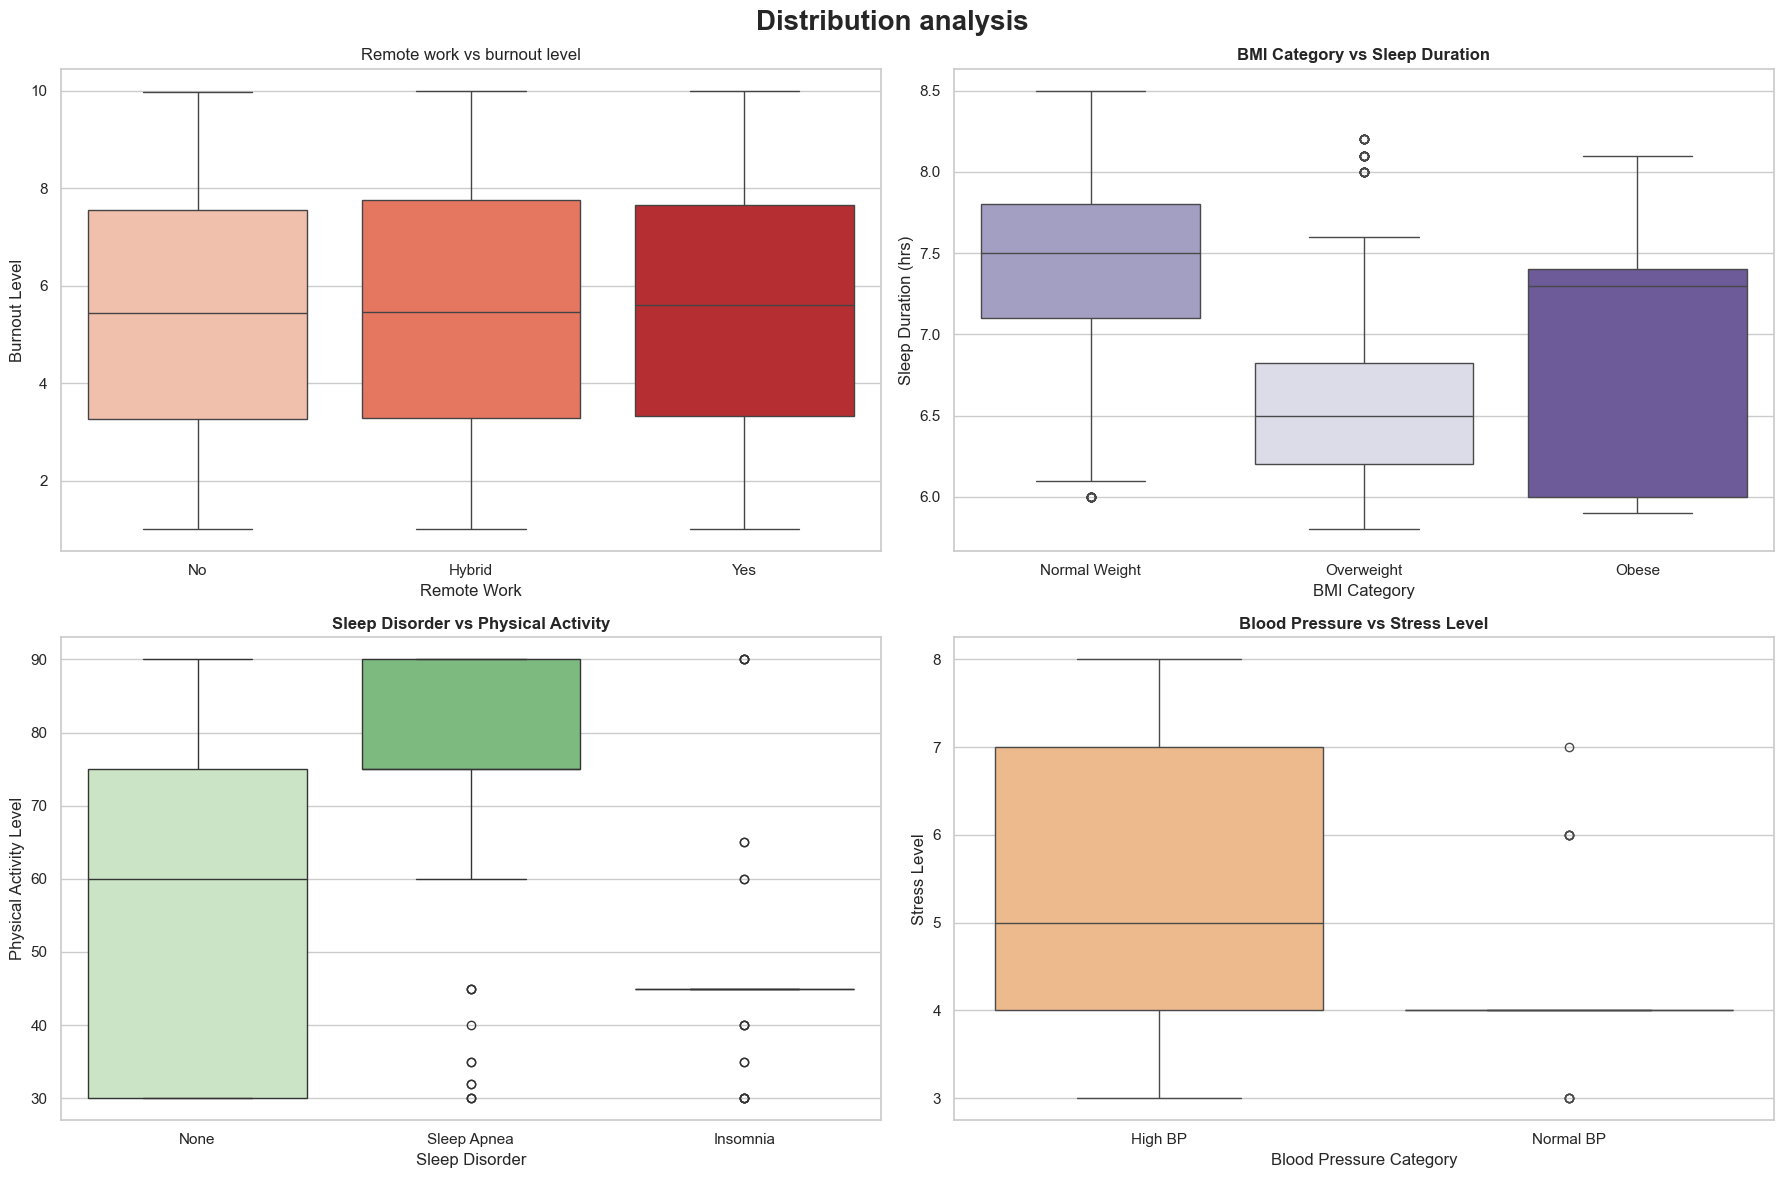

Box plots saved!


In [41]:
fig,axes= plt.subplots(2,2,figsize=(18,12))
fig.suptitle("Distribution analysis",fontsize=20,fontweight='bold')

#1. remote work vs burnout
sns.boxplot(ax=axes[0,0],data=final_merged_df,x='remote_work',y='burnout_level',palette='Reds',hue='remote_work',legend=False)
axes[0,0].set_title('Remote work vs burnout level')
axes[0,0].set_xlabel('Remote Work')
axes[0,0].set_ylabel('Burnout Level')

# 2. Category vs Sleep Disorder
bmi_order = ['Normal Weight', 'Overweight', 'Obese']
sns.boxplot(ax=axes[0,1], data=sleep_df,
            x='bmi_category', y='sleep_duration',
            order=bmi_order,
            palette='Purples', hue='bmi_category', legend=False)
axes[0,1].set_title('BMI Category vs Sleep Duration', fontweight='bold')
axes[0,1].set_xlabel('BMI Category')
axes[0,1].set_ylabel('Sleep Duration (hrs)')

# 3. Physical Activity vs Sleep Quality
sns.boxplot(ax=axes[1,0], data=sleep_df,
            x='sleep_disorder', y='physical_activity_level',
            palette='Greens', hue='sleep_disorder', legend=False)
axes[1,0].set_title('Sleep Disorder vs Physical Activity', fontweight='bold')
axes[1,0].set_xlabel('Sleep Disorder')
axes[1,0].set_ylabel('Physical Activity Level')

# 4. High BP vs Stress Level
sleep_df['high_bp_label'] = sleep_df['high_bp'].map({True: 'High BP', False: 'Normal BP'})
sns.boxplot(ax=axes[1,1], data=sleep_df,
            x='high_bp_label', y='stress_level',
            palette='Oranges', hue='high_bp_label', legend=False)
axes[1,1].set_title('Blood Pressure vs Stress Level', fontweight='bold')
axes[1,1].set_xlabel('Blood Pressure Category')
axes[1,1].set_ylabel('Stress Level')

plt.tight_layout()
plt.savefig('boxplot_analysis.png', dpi=150)
plt.show()
print("Box plots saved!")


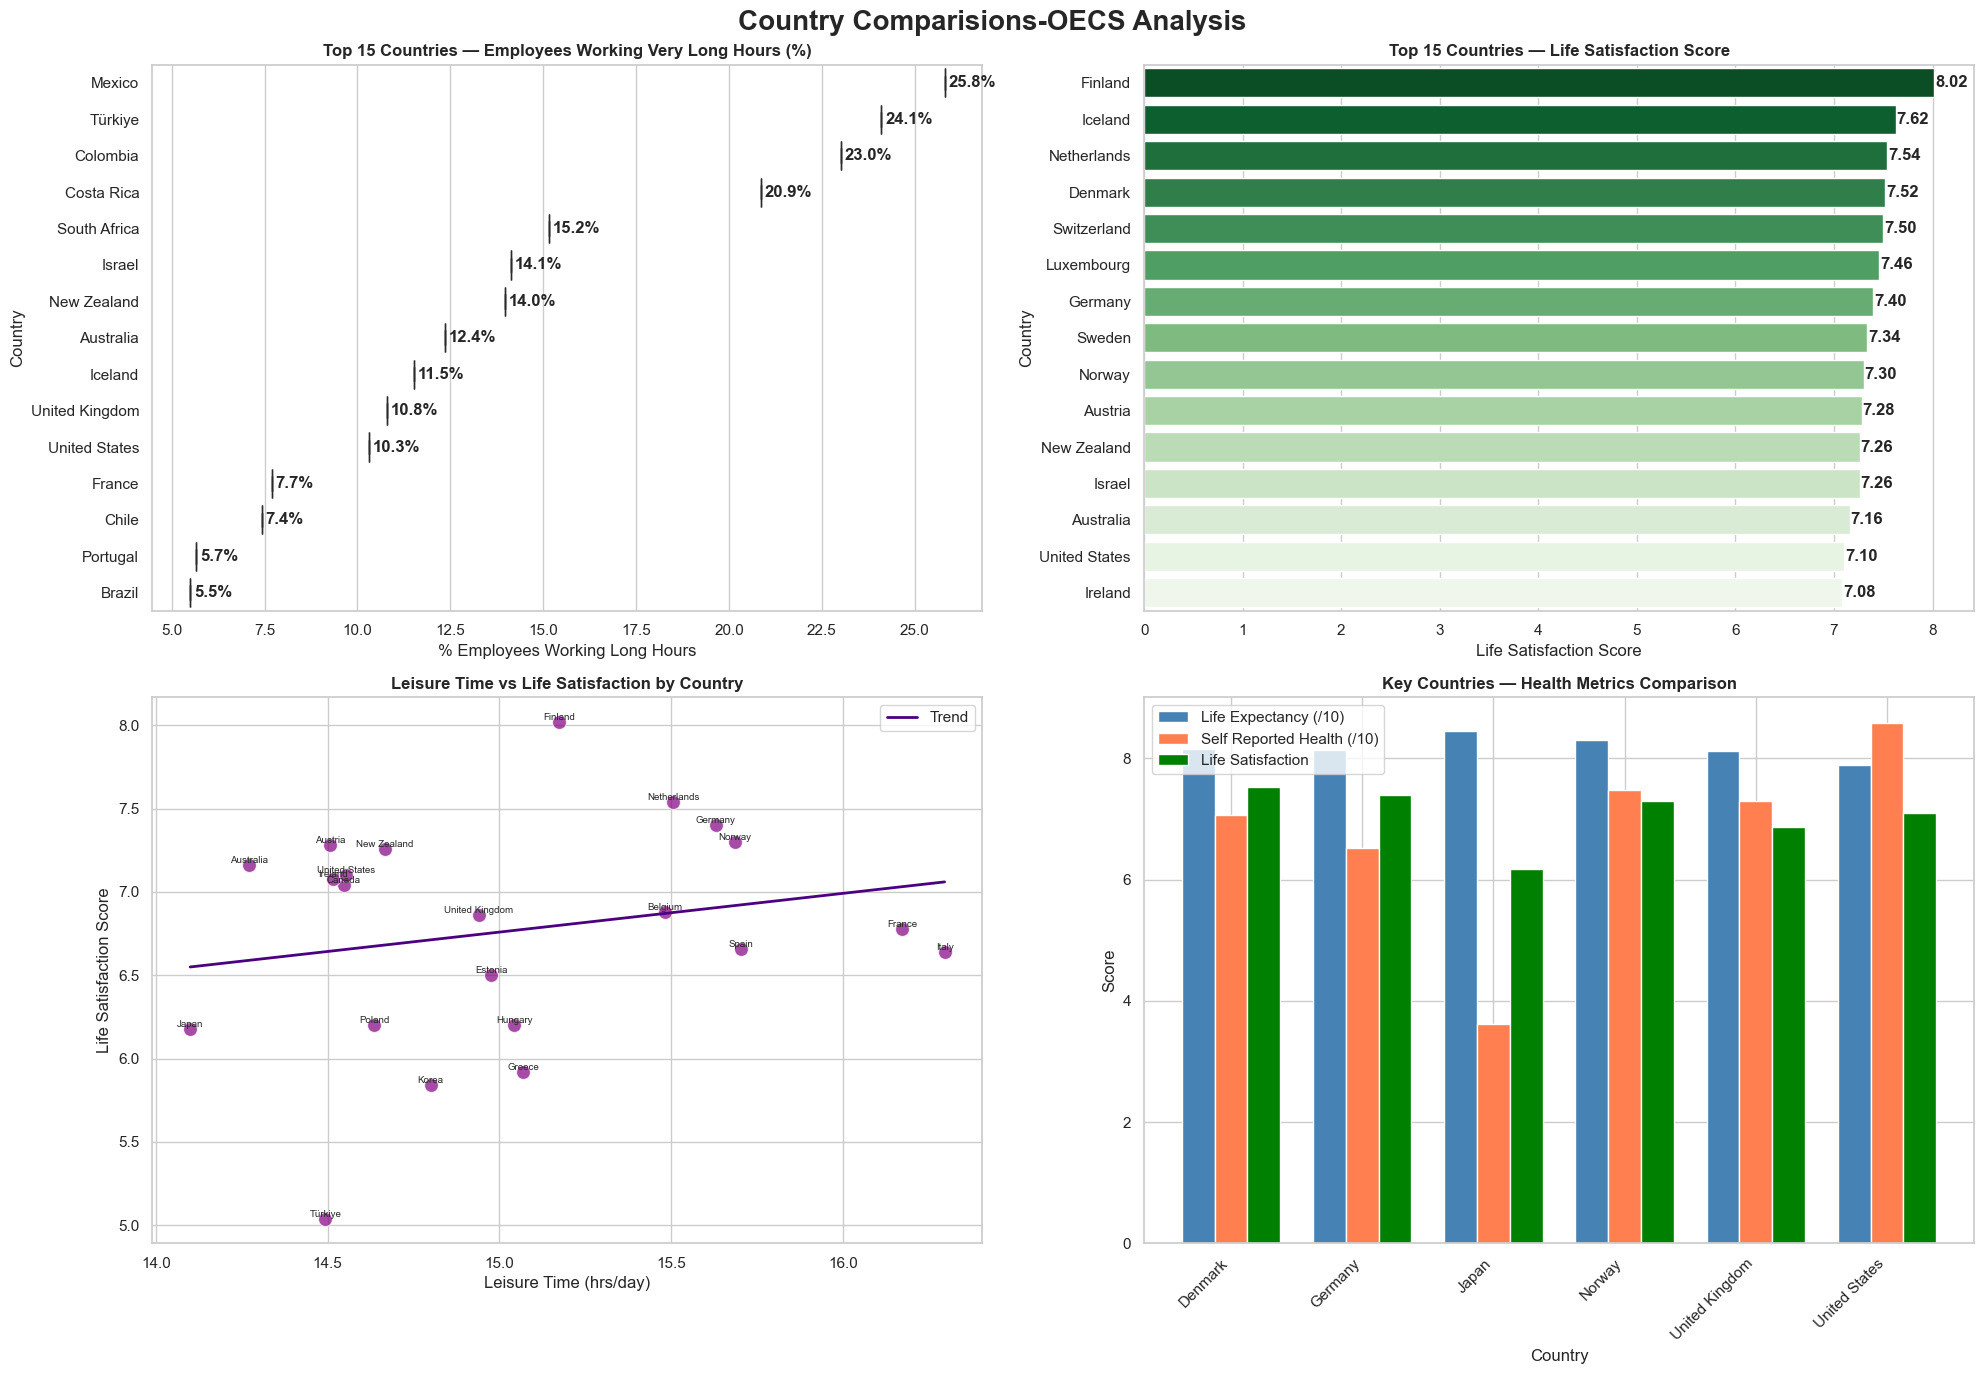

Country comparison charts saved!


In [42]:
fig,axes=plt.subplots(2,2,figsize=(20,14))
fig.suptitle("Country Comparisions-OECS Analysis",fontsize=20,fontweight='bold')

#1. countries with most overworked employees
overwork=oecd_wide[['country','employees_working_very_long_hours']].dropna()
overwork=overwork.sort_values('employees_working_very_long_hours',ascending=False).head(15)
sns.boxplot(ax=axes[0,0],data=overwork,x='employees_working_very_long_hours', y='country',
            palette='Reds_r', hue='country', legend=False)
axes[0,0].set_title('Top 15 Countries — Employees Working Very Long Hours (%)', fontweight='bold')
axes[0,0].set_xlabel('% Employees Working Long Hours')
axes[0,0].set_ylabel('Country')
for i, v in enumerate(overwork['employees_working_very_long_hours']):
    axes[0,0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontweight='bold')

# 2. Countries with Highest Life Satisfaction
life_sat = oecd_wide[['country', 'life_satisfaction']].dropna()
life_sat = life_sat.sort_values('life_satisfaction', ascending=False).head(15)

sns.barplot(ax=axes[0,1], data=life_sat,
            x='life_satisfaction', y='country',
            palette='Greens_r', hue='country', legend=False)
axes[0,1].set_title('Top 15 Countries — Life Satisfaction Score', fontweight='bold')
axes[0,1].set_xlabel('Life Satisfaction Score')
axes[0,1].set_ylabel('Country')
for i, v in enumerate(life_sat['life_satisfaction']):
    axes[0,1].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')  

# Q16 - Leisure Time vs Life Satisfaction
leisure = oecd_wide[['country', 'time_devoted_to_leisure_and_personal_care', 
                      'life_satisfaction']].dropna()

sns.scatterplot(ax=axes[1,0], data=leisure,
                x='time_devoted_to_leisure_and_personal_care',
                y='life_satisfaction',
                s=100, color='purple', alpha=0.7)

# Add country labels on dots
for idx, row in leisure.iterrows():
    axes[1,0].annotate(row['country'], 
                       (row['time_devoted_to_leisure_and_personal_care'], 
                        row['life_satisfaction']),
                       fontsize=7, ha='center', va='bottom')
# Trend line
m, b = np.polyfit(leisure['time_devoted_to_leisure_and_personal_care'],
                   leisure['life_satisfaction'], 1)
x_vals = sorted(leisure['time_devoted_to_leisure_and_personal_care'])
axes[1,0].plot(x_vals, [m*x+b for x in x_vals], 
               color='darkpurple' if False else 'indigo', 
               linewidth=2, label='Trend')
axes[1,0].set_title('Leisure Time vs Life Satisfaction by Country', fontweight='bold')
axes[1,0].set_xlabel('Leisure Time (hrs/day)')
axes[1,0].set_ylabel('Life Satisfaction Score')
axes[1,0].legend()

# Q17 - Key Countries Health Comparison
key_countries = ['India', 'Brazil', 'Japan', 'Germany', 
                 'Denmark', 'Norway', 'United States', 'United Kingdom']
health_compare = oecd_wide[oecd_wide['country'].isin(key_countries)][
    ['country', 'life_expectancy', 'self_reported_health', 'life_satisfaction']
].dropna()

x = np.arange(len(health_compare['country']))
width = 0.25

axes[1,1].bar(x - width, health_compare['life_expectancy']/10, 
              width, label='Life Expectancy (/10)', color='steelblue')
axes[1,1].bar(x, health_compare['self_reported_health']/10, 
              width, label='Self Reported Health (/10)', color='coral')
axes[1,1].bar(x + width, health_compare['life_satisfaction'], 
              width, label='Life Satisfaction', color='green')

axes[1,1].set_title('Key Countries — Health Metrics Comparison', fontweight='bold')
axes[1,1].set_xlabel('Country')
axes[1,1].set_ylabel('Score')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(health_compare['country'], rotation=45, ha='right')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('country_comparison.png', dpi=150)
plt.show()
print("Country comparison charts saved!")
    

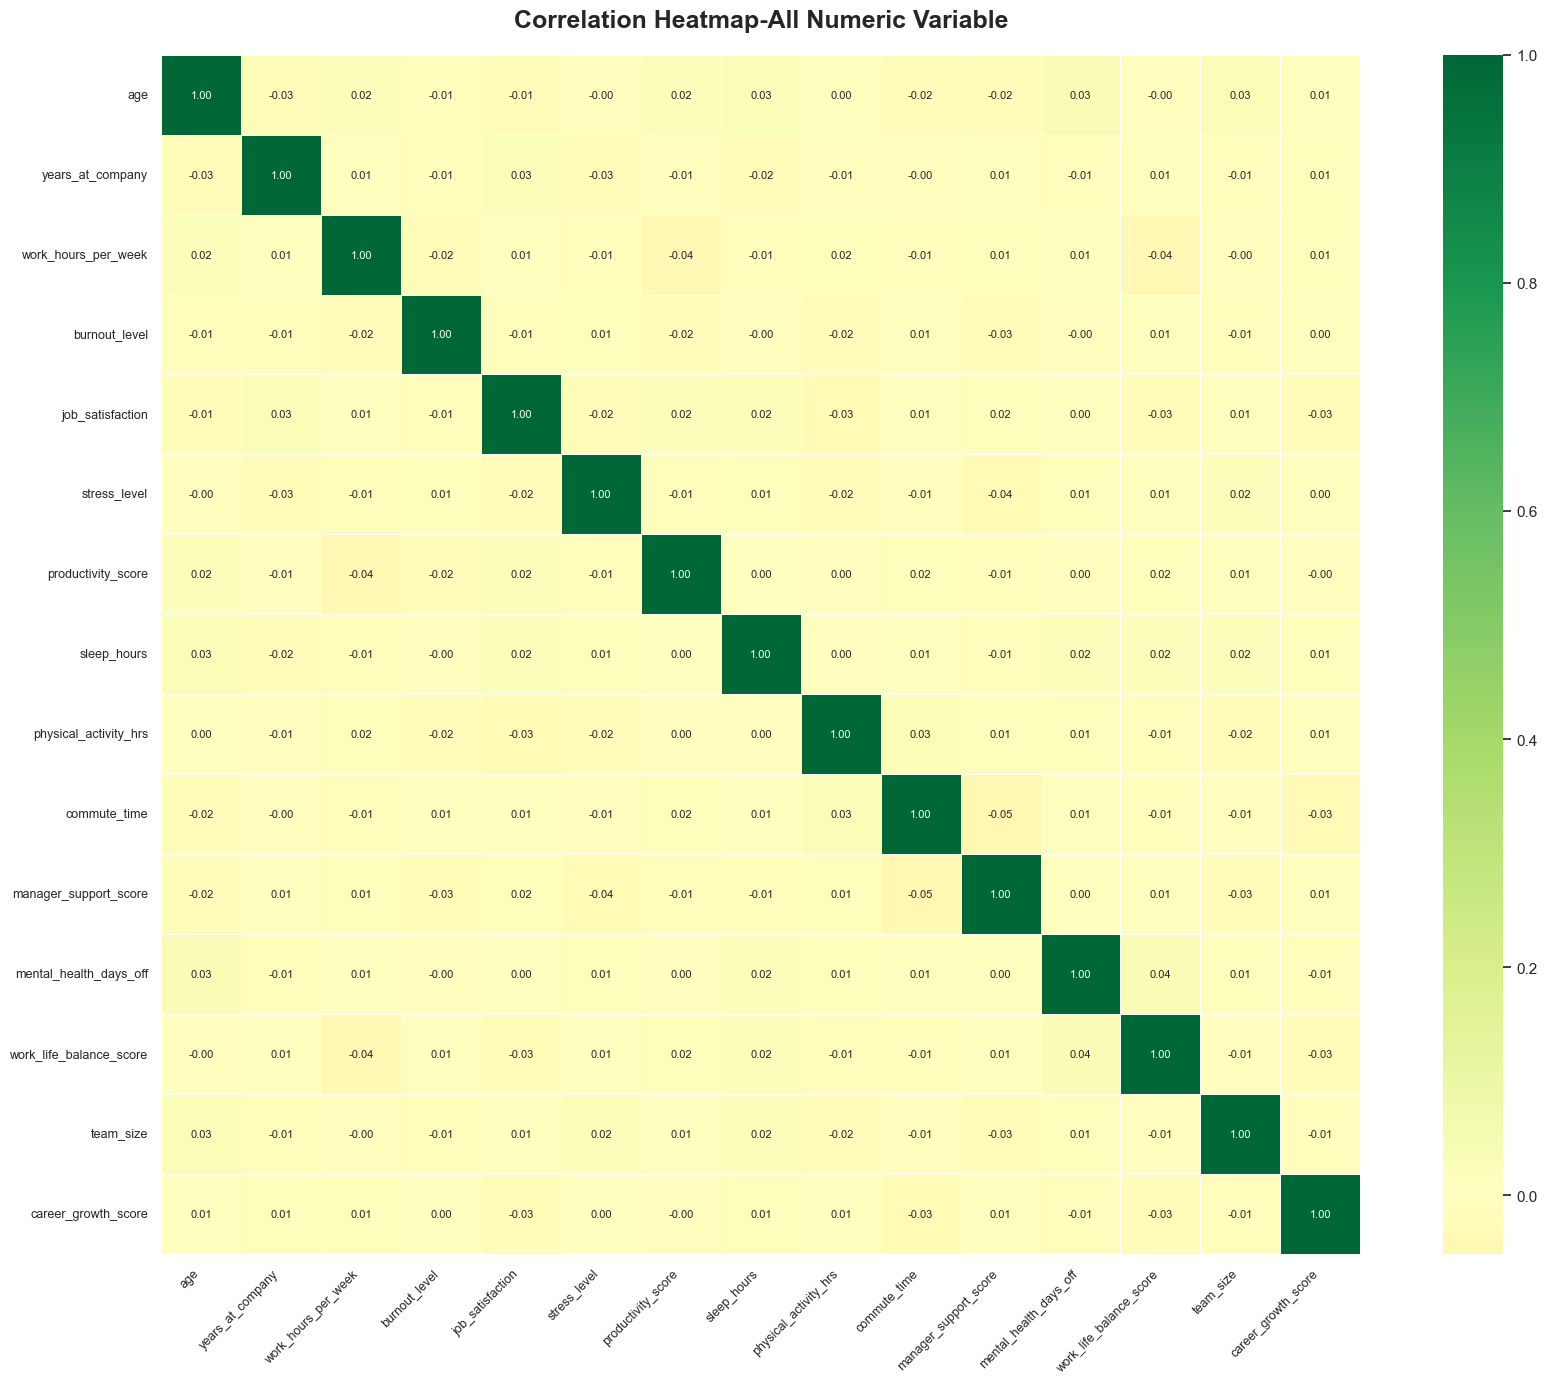

Heatmap saved!


In [43]:
#correlation heatmap
plt.figure(figsize=(18,14))
numeric_cols=['age', 'years_at_company', 'work_hours_per_week', 
                'burnout_level', 'job_satisfaction', 'stress_level',
                'productivity_score', 'sleep_hours', 'physical_activity_hrs',
                'commute_time', 'manager_support_score', 'mental_health_days_off',
                'work_life_balance_score', 'team_size', 'career_growth_score']

corr_matrix=final_merged_df[numeric_cols].corr() #correlation
sns.heatmap(corr_matrix,
           annot=True,
           fmt='.2f',
           cmap='RdYlGn',
           center=0,
           square=True,
           linewidth=0.5,
           annot_kws={'size':8})

plt.title('Correlation Heatmap-All Numeric Variable',
         fontsize=18,fontweight='bold',pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved!")


In [44]:
import pandas as pd

# Reload and re-save properly
burnout = pd.read_csv('Cleaned_datasets/final_merged_burnout_oecd.csv')
sleep = pd.read_csv('Cleaned_datasets/sleep_df.csv')
oecd = pd.read_csv('Cleaned_datasets/oecd_wide_country_data.csv')

# Re-save with explicit settings
burnout.to_csv('burnout_clean.csv', index=False, sep=',', encoding='utf-8-sig')
sleep.to_csv('sleep_clean.csv', index=False, sep=',', encoding='utf-8-sig')
oecd.to_csv('oecd_clean.csv', index=False, sep=',', encoding='utf-8-sig')

print("✅ Files re-saved!")
print(burnout.shape)
print(sleep.shape)
print(oecd.shape)

✅ Files re-saved!
(3000, 37)
(374, 18)
(41, 10)


In [45]:
#for power bi import pandas as pd

# Load all files
df = pd.read_csv('Cleaned_datasets/final_merged_burnout_oecd.csv')
sleep = pd.read_csv('Cleaned_datasets/sleep_df.csv')


# File 1 — Burnout columns
burnout_cols = ['employee_id', 'age', 'gender', 'country', 'job_role', 
                'department', 'years_at_company', 'work_hours_per_week',
                'remote_work', 'burnout_level', 'job_satisfaction', 
                'stress_level', 'productivity_score', 'sleep_hours',
                'physical_activity_hrs', 'commute_time', 
                'has_mental_health_support', 'manager_support_score',
                'has_therapy_access', 'mental_health_days_off',
                'salary_range', 'work_life_balance_score', 'team_size',
                'career_growth_score', 'burnout_risk', 'high_burnout',
                'overworked', 'age_group']

# File 2 — OECD columns
oecd_cols = ['country', 'air_pollution', 'employees_working_very_long_hours',
             'employment_rate', 'life_expectancy', 'life_satisfaction',
             'long_term_unemployment_rate', 'self_reported_health',
             'time_devoted_to_leisure_and_personal_care', 'water_quality']

# File 3 — Sleep columns (all of them, already small)
sleep_cols = ['person_id', 'gender', 'age', 'occupation',
              'sleep_duration', 'quality_of_sleep',
              'physical_activity_level', 'stress_level',
              'bmi_category', 'blood_pressure', 'heart_rate',
              'daily_steps', 'sleep_disorder', 'systolic_bp',
              'diastolic_bp', 'age_group', 'high_bp', 'poor_sleep']

# Save all 3 files
df[burnout_cols].to_csv('powerbi_burnout.csv', index=False, encoding='utf-8-sig')
df[oecd_cols].drop_duplicates(subset=['country']).to_csv('powerbi_oecd.csv', index=False, encoding='utf-8-sig')
sleep[sleep_cols].to_csv('powerbi_sleep.csv', index=False, encoding='utf-8-sig')

print("\n All 3 files saved!")
print("Burnout columns:", len(burnout_cols))
print("OECD columns:", len(oecd_cols))
print("Sleep columns:", len(sleep_cols))


 All 3 files saved!
Burnout columns: 28
OECD columns: 10
Sleep columns: 18


In [46]:
sleep=pd.read_csv('sleep_clean.csv')
sleep.to_excel('powerbi_sleep.xlsx',index=False)
print('saved')

saved


In [47]:
df = pd.read_csv('burnout_clean.csv')
print(df['burnout_risk'].value_counts())
print(df['burnout_risk'].unique())
print("Sum:", df['burnout_risk'].sum())

burnout_risk
0    2020
1     980
Name: count, dtype: int64
[0 1]
Sum: 980


In [48]:
import pandas as pd

# Load the ORIGINAL full OECD wide data
oecd_full = pd.read_csv('Cleaned_datasets/oecd_wide_country_data.csv')

print("Shape:", oecd_full.shape)
print("Countries:", oecd_full['country'].nunique())
print(oecd_full['country'].tolist())

# Save for Power BI
oecd_full.to_excel('powerbi_oecd_full.xlsx', index=False)
print("Full OECD file saved!")

Shape: (41, 10)
Countries: 41
['Australia', 'Austria', 'Belgium', 'Brazil', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Portugal', 'Russia', 'Slovak Republic', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 'United Kingdom', 'United States']
Full OECD file saved!
